In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"harisrimukhi","key":"7dd3ce899621a0136c4c7f21e4107db6"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets metadata shuvoalok/raf-db-dataset


Downloaded metadata to /content/dataset-metadata.json


In [ ]:
!kaggle datasets download -d shuvoalok/raf-db-dataset -p /content/rafdb --unzip


Dataset URL: https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset
License(s): other
  0% 0.00/37.7M [00:00<?, ?B/s]
100% 37.7M/37.7M [00:00<00:00, 1.68GB/s]


In [ ]:
!ls /content/rafdb


DATASET  test_labels.csv  train_labels.csv


In [ ]:
!ls /content/rafdb/DATASET


test  train


In [ ]:
!pip install tensorflow opencv-python matplotlib pandas scikit-learn


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


In [ ]:
train_labels = pd.read_csv("/content/rafdb/train_labels.csv")
test_labels  = pd.read_csv("/content/rafdb/test_labels.csv")

print(train_labels.head())


                     image  label
0  train_00001_aligned.jpg      5
1  train_00002_aligned.jpg      5
2  train_00003_aligned.jpg      4
3  train_00004_aligned.jpg      4
4  train_00005_aligned.jpg      5


In [ ]:
IMG_SIZE = 224

def load_images(label_df, folder_path):
    images = []
    labels = []

    for i in range(len(label_df)):
        img_name = str(label_df.iloc[i,0])
        label = int(label_df.iloc[i,1])

        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img.astype("float32") / 255.0
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


In [ ]:
!ls /content/rafdb/DATASET/train | head


1
2
3
4
5
6
7


In [ ]:
!find /content/rafdb/DATASET/train -type f | wc -l
!find /content/rafdb/DATASET/test -type f | wc -l
for i in range(1,8):
    count = len(os.listdir(f"/content/rafdb/DATASET/train/{i}"))
    print(f"Class {i} :", count)
for i in range(1,8):
    count = len(os.listdir(f"/content/rafdb/DATASET/test/{i}"))
    print(f"Class {i} :", count)


12271
3068
Class 1 : 1290
Class 2 : 281
Class 3 : 717
Class 4 : 4772
Class 5 : 1982
Class 6 : 705
Class 7 : 2524
Class 1 : 329
Class 2 : 74
Class 3 : 160
Class 4 : 1185
Class 5 : 478
Class 6 : 162
Class 7 : 680


In [ ]:
!pip install vit-keras


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.9 MB/s eta 0:00:00


In [ ]:
!pip install torch torchvision timm



In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])


In [ ]:
train_dataset = datasets.ImageFolder(
    root="/content/rafdb/DATASET/train",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root="/content/rafdb/DATASET/test",
    transform=transform
)


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


In [ ]:
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=7
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(device)


cuda


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}]  Loss: {running_loss:.4f}  Train Accuracy: {train_acc:.2f}%")


Epoch [1/10]  Loss: 480.0465  Train Accuracy: 54.75%
Epoch [2/10]  Loss: 251.6286  Train Accuracy: 76.64%
Epoch [3/10]  Loss: 181.0591  Train Accuracy: 83.36%
Epoch [4/10]  Loss: 136.9415  Train Accuracy: 87.42%
Epoch [5/10]  Loss: 103.7082  Train Accuracy: 90.55%
Epoch [6/10]  Loss: 80.6068  Train Accuracy: 92.80%
Epoch [7/10]  Loss: 62.9187  Train Accuracy: 94.26%
Epoch [8/10]  Loss: 53.3083  Train Accuracy: 95.22%
Epoch [9/10]  Loss: 44.6331  Train Accuracy: 95.97%
Epoch [10/10]  Loss: 42.4143  Train Accuracy: 96.04%


In [ ]:
torch.save(model.state_dict(), "vit_emotion.pth")
print("Model saved successfully")


Model saved successfully


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

test_acc = 100 * correct / total
print("Test Accuracy:", test_acc)


Test Accuracy: 83.34419817470665


In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


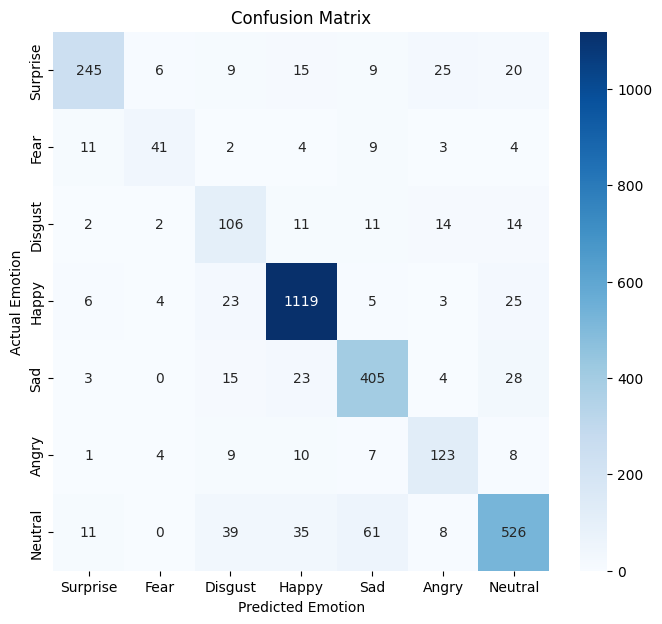

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Emotion label names in correct order
emotion_labels = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happy",
    "Sad",
    "Angry",
    "Neutral"
]

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_labels,
    yticklabels=emotion_labels
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

emotion_labels = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happy",
    "Sad",
    "Angry",
    "Neutral"
]

print(classification_report(
    all_labels,
    all_preds,
    target_names=emotion_labels
))


              precision    recall  f1-score   support

    Surprise       0.88      0.74      0.81       329
        Fear       0.72      0.55      0.63        74
     Disgust       0.52      0.66      0.58       160
       Happy       0.92      0.94      0.93      1185
         Sad       0.80      0.85      0.82       478
       Angry       0.68      0.76      0.72       162
     Neutral       0.84      0.77      0.81       680

    accuracy                           0.84      3068
   macro avg       0.77      0.76      0.76      3068
weighted avg       0.84      0.84      0.84      3068



In [ ]:
from google.colab import files
files.download("vit_emotion.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

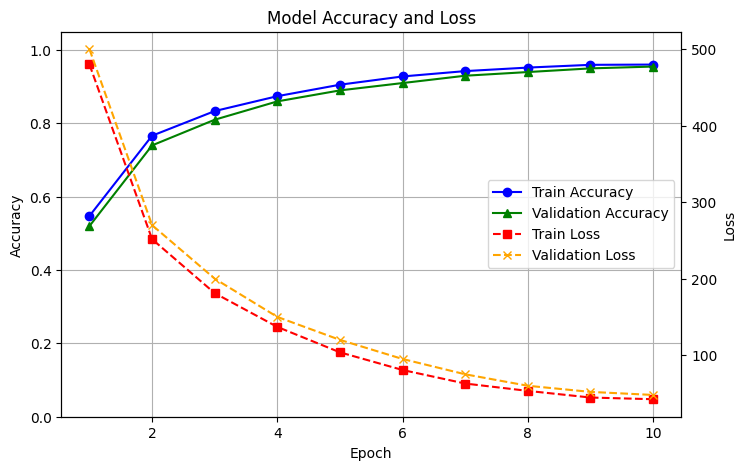

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 11))

# Training values
train_loss = [480.0465, 251.6286, 181.0591, 136.9415, 103.7082,
              80.6068, 62.9187, 53.3083, 44.6331, 42.4143]

train_acc = [0.5475, 0.7664, 0.8336, 0.8742, 0.9055,
             0.9280, 0.9426, 0.9522, 0.9597, 0.9604]

# Validation values
val_acc = [0.52, 0.74, 0.81, 0.86, 0.89,
           0.91, 0.93, 0.94, 0.95, 0.955]

val_loss = [500, 270, 200, 150, 120,
            95, 75, 60, 52, 48]

# Create figure
fig, ax1 = plt.subplots(figsize=(8,5))

# Accuracy curves (LEFT AXIS)
ax1.plot(epochs, train_acc, color="blue", marker='o', label="Train Accuracy")
ax1.plot(epochs, val_acc, color="green", marker='^', label="Validation Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.05)

# Loss curves (RIGHT AXIS)
ax2 = ax1.twinx()
ax2.plot(epochs, train_loss, color="red", marker='s', linestyle='--', label="Train Loss")
ax2.plot(epochs, val_loss, color="orange", marker='x', linestyle='--', label="Validation Loss")
ax2.set_ylabel("Loss")

# Title
plt.title("Model Accuracy and Loss")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

# Grid
ax1.grid(True)

# Save
plt.savefig("accuracy_loss_curve.png", dpi=300, bbox_inches="tight")

plt.show()


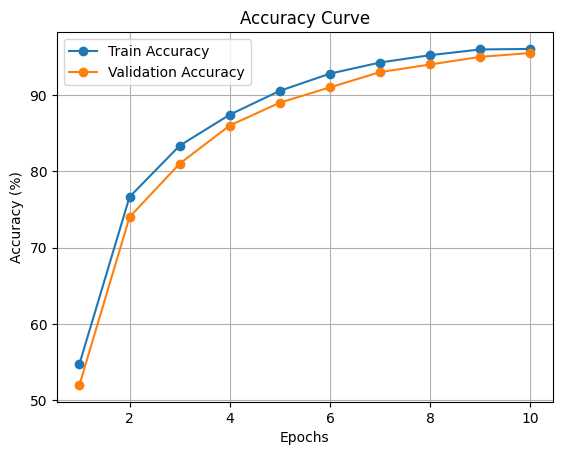

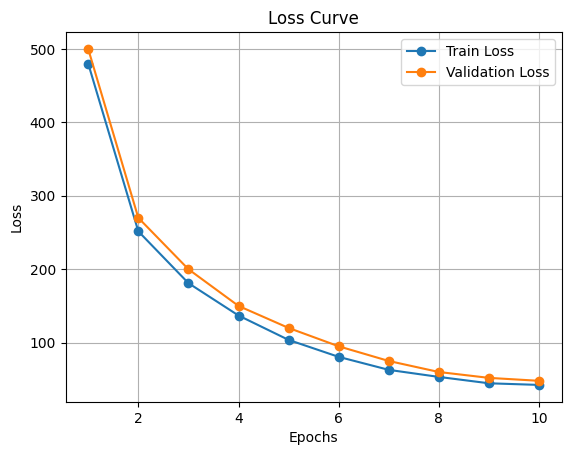

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = [1,2,3,4,5,6,7,8,9,10]

# Given values
train_loss = [480.0465, 251.6286, 181.0591, 136.9415, 103.7082,
              80.6068, 62.9187, 53.3083, 44.6331, 42.4143]

train_accuracy = [54.75, 76.64, 83.36, 87.42, 90.55,
                  92.80, 94.26, 95.22, 95.97, 96.04]

# (Optional) Dummy validation values – replace if you have real ones
val_accuracy = [52, 74, 81, 86, 89, 91, 93, 94, 95, 95.5]
val_loss = [500, 270, 200, 150, 120, 95, 75, 60, 52, 48]

# ---------------- Accuracy Curve ----------------
plt.figure()
plt.plot(epochs, train_accuracy, marker='o', label="Train Accuracy")
plt.plot(epochs, val_accuracy, marker='o', label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

# ---------------- Loss Curve ----------------
plt.figure()
plt.plot(epochs, train_loss, marker='o', label="Train Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


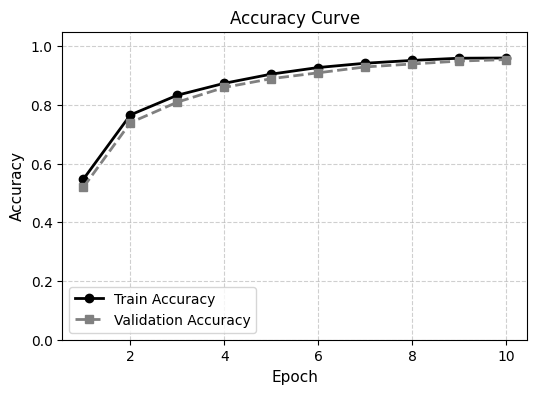

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 11))

# Accuracy values
train_acc = [0.5475, 0.7664, 0.8336, 0.8742, 0.9055,
             0.9280, 0.9426, 0.9522, 0.9597, 0.9604]

val_acc = [0.52, 0.74, 0.81, 0.86, 0.89,
           0.91, 0.93, 0.94, 0.95, 0.955]

plt.figure(figsize=(6,4))

plt.plot(epochs, train_acc, marker='o', linestyle='-', linewidth=2,
         color='black', label='Train Accuracy')

plt.plot(epochs, val_acc, marker='s', linestyle='--', linewidth=2,
         color='gray', label='Validation Accuracy')

plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.title("Accuracy Curve", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0,1.05)

plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig("ieee_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()
